# Model: Baseline

Owner: **Xavier**

## Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

INCLUDE_RADIATION_DAY_BEFORE = False

MODEL_NAME = "baseline" if INCLUDE_RADIATION_DAY_BEFORE else "baseline_no_radiation_day_before"

## Load preprocessed data

In [2]:
# Set data path:
DATA_DIR = Path('/Users/xaviersun/UNSW_Projects/ZZSC9020-group-A/data/NSW')
RESULTS_DIR = Path('/Users/xaviersun/UNSW_Projects/ZZSC9020-group-A/results')

TARGET = "TOTALDEMAND"
TRAIN_END = '2017-12-31 23:30:00'
VAL = ('2018-01-01 00:00:00', '2018-12-31 23:30:00')
TEST = ('2019-01-01 00:00:00', '2019-12-31 23:30:00')

# Load data: train, test and validation, and features
train = pd.read_csv(DATA_DIR / "nsw_train.csv", parse_dates=["DATETIME"]).set_index("DATETIME").sort_index()
test = pd.read_csv(DATA_DIR / "nsw_test.csv", parse_dates=["DATETIME"]).set_index("DATETIME").sort_index()
validation = pd.read_csv(DATA_DIR / "nsw_validation.csv", parse_dates=["DATETIME"]).set_index("DATETIME").sort_index()

print(f"train: {train.index.min()} -> {train.index.max()}  ({len(train)} rows)")
print(f"test:  {test.index.min()} -> {test.index.max()}  ({len(test)} rows)")
print(f"validation:  {validation.index.min()} -> {validation.index.max()}  ({len(validation)} rows)")

train: 2010-01-02 00:00:00 -> 2017-12-31 23:30:00  (140208 rows)
test:  2019-01-01 00:00:00 -> 2019-12-31 23:30:00  (17520 rows)
validation:  2018-01-01 00:00:00 -> 2018-12-31 23:30:00  (17520 rows)


## Features and target

In [3]:
# 0. Set target and features:
TARGET = "TOTALDEMAND"
DROP_COLS = ['DATETIME', TARGET, 'TEMPERATURE', 'radiation', 'forecast_closest','forecast_12hr_prior','forecast_dayprior']
if not INCLUDE_RADIATION_DAY_BEFORE:
    DROP_COLS.append("radiation_day_before")
FEATURES = [c for c in train.columns if c not in DROP_COLS]
print(f'FEATURES: {FEATURES}')

continuous_features = [col for col in FEATURES if not col.startswith(('day_', 'hour_', 'month_'))]
print(f'CONTINUOUS_FEATURES: {continuous_features}')
print(f'{len(FEATURES)} features: {continuous_features}')
print(f"   plus {sum(col.startswith('day_') for col in FEATURES)} day, "
      f"{sum(col.startswith('hour_') for col in FEATURES)} hour and "
      f"{sum(col.startswith('month_') for col in FEATURES)} month one-hot columns")

FEATURES: ['is_public_holiday', 'is_school_term', 'temperature_day_before', 'demand_day_before', 'day_Friday', 'day_Monday', 'day_Saturday', 'day_Sunday', 'day_Thursday', 'day_Tuesday', 'day_Wednesday', 'hour_0', 'hour_1', 'hour_2', 'hour_3', 'hour_4', 'hour_5', 'hour_6', 'hour_7', 'hour_8', 'hour_9', 'hour_10', 'hour_11', 'hour_12', 'hour_13', 'hour_14', 'hour_15', 'hour_16', 'hour_17', 'hour_18', 'hour_19', 'hour_20', 'hour_21', 'hour_22', 'hour_23', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']
CONTINUOUS_FEATURES: ['is_public_holiday', 'is_school_term', 'temperature_day_before', 'demand_day_before']
47 features: ['is_public_holiday', 'is_school_term', 'temperature_day_before', 'demand_day_before']
   plus 7 day, 24 hour and 12 month one-hot columns


## Data Checks

In [4]:
demand = pd.concat([train[TARGET], validation[TARGET], test[TARGET]]).asfreq('30min')
print(f'1. Joined target: {demand.index.min()} -> {demand.index.max()}, '
      f'{demand.isna().sum()} gaps, {demand.index.duplicated().sum()} duplicate timestamps')

scaled = ['temperature_day_before', 'radiation_day_before', 'demand_day_before']
print(f'''\n2. Scaled features: a mean of 0 and standard deviation of 1 in train alone means
the scaler saw only the training years, hence, no test information leaks in through scaling:
         {pd.DataFrame({'train_mean': train[scaled].mean(),
                        'train_std': train[scaled].std(),
                        'validation_mean': validation[scaled].mean(),
                        'test_mean': test[scaled].mean()}).round(3).to_string()}''')

lag48 = demand.shift(48).reindex(train.index)
ok = lag48.notna()
print(f'''\n3. corr(demand_day_before, target at t-48) = {np.corrcoef(train.loc[ok, 'demand_day_before'], lag48[ok])[0, 1]:.6f}''')

print('\n4. Mean demand (MW): ' + ', '.join(
    f'{n} {f[TARGET].mean():,.0f}' for n, f in [('train', train), ('validation', validation), ('test', test)]))

1. Joined target: 2010-01-02 00:00:00 -> 2019-12-31 23:30:00, 0 gaps, 0 duplicate timestamps

2. Scaled features: a mean of 0 and standard deviation of 1 in train alone means
the scaler saw only the training years, hence, no test information leaks in through scaling:
                                 train_mean  train_std  validation_mean  test_mean
temperature_day_before        -0.0        1.0            0.033      0.068
radiation_day_before           0.0        1.0            0.090      0.157
demand_day_before             -0.0        1.0           -0.165     -0.189

3. corr(demand_day_before, target at t-48) = 1.000000

4. Mean demand (MW): train 8,213, validation 8,000, test 7,965


####  Based on the above data checks:
* `demand_day_before` is exactly the 48-period lag, hence, the naive same-time-yesterday baseline is the raw value of a feature every model already has.
* Demand in 2018-2019 sits well below the 2010-2017 average, the long-run decline found in the EDA, that is, any model that learns a fixed level from the training years over-rdict the test year.

## Baselines: Naive & Calendar

In [5]:
naive = pd.DataFrame({
    'Naive (same time yesterday)': demand.shift(48),
    'Naive (same time last week)': demand.shift(336),
})
naive['Naive blend'] = naive.mean(axis=1, skipna=False)

SEASON_MAP = {1: 'Summer', 2: 'Summer', 3: 'Autumn', 4: 'Autumn', 5: 'Autumn', 6: 'Winter',
              7: 'Winter', 8: 'Winter', 9: 'Spring', 10: 'Spring', 11: 'Spring', 12: 'Summer'}

def calendar(index):
    df = pd.DataFrame({
        'SEASON': index.month.map(SEASON_MAP),
        'DAY_TYPE': np.where(index.dayofweek >= 5, 'Weekend', 'Weekday'),
        'PERIOD': index.hour * 2 + index.minute // 30,
    }, index=index)
    return df

cal_train = calendar(train.index)
profile = (pd.concat([cal_train, train[TARGET]], axis=1)
             .groupby(['SEASON', 'DAY_TYPE', 'PERIOD'])[TARGET].mean().rename('Climatology Profile'))
print(f'Climatology profile: {len(profile)} season x day_type x half-hour cells, from the training years.')

Climatology profile: 384 season x day_type x half-hour cells, from the training years.


## Baseline: Linear Regression
* Ordinary least squares on all 48 features, fitted on the training years.
* With nothing to tune, the validation year is used only to confirm the test result is not a one-year accident.

In [6]:
linear = LinearRegression().fit(train[FEATURES], train[TARGET])
print(f'Fitted on {len(train):,} training rows, {len(FEATURES):,} features')

Fitted on 140,208 training rows, 47 features


## Model Predictions

In [7]:
# Prediction - Linear :
def predictions(df):
    out = naive.reindex(df.index).copy()
    out['Climatology Profile'] = calendar(df.index).join(profile, on=['SEASON', 'DAY_TYPE', 'PERIOD'])['Climatology Profile']
    out['Linear Regression'] = linear.predict(df[FEATURES])
    return out

preds = {'Validation 2018': predictions(validation), 'Test 2019': predictions(test)}
actuals = {'Validation 2018': validation[TARGET], 'Test 2019': test[TARGET]}

## Validation checklist

Every model notebook uses this same function, so the numbers are computed the same way for everyone:
- **RMSE**: root mean squared error, in MW
- **MAE**: mean absolute error, in MW
- **MAPE**: mean absolute percentage error, in %
- **R²**: coefficient of determination, the share of demand variation the model explains (0 to 1 scale)

In [8]:
# Model Evaluation - Metrics:
def evaluate(actual, predicted, model=MODEL_NAME):
    v = pd.concat([actual, predicted], axis=1).dropna()
    act = v.iloc[:, 0]
    pred = v.iloc[:, 1]
    mae = mean_absolute_error(act, pred)
    mape = mean_absolute_percentage_error(act, pred) * 100
    rmse = np.sqrt(mean_squared_error(act, pred))
    r2 = r2_score(act, pred)
    bias = (act - pred).mean()
    metrics = {'Model': model, 'MAE (MW)': mae, 'RMSE (MW)': rmse, 'MAPE (%)': mape,
               'r2': r2, 'Bias (MW)': bias, 'n': len(v)}
    return metrics

## Results: Baseline Comparisons

In [9]:
results = {}
for pred in preds:
    result = (pd.DataFrame({m: evaluate(actuals[pred], preds[pred][m]) for m in preds[pred]})
             .T.sort_values('MAE (MW)'))
    results[pred] = result
    print(f'\n{pred} (bias = actual - forecast; where negative means overprediction)')
    print(results[pred].to_string(float_format=lambda x: f'{x:,.1f}'))
    print('-'*80)


Validation 2018 (bias = actual - forecast; where negative means overprediction)
                                                        Model MAE (MW) RMSE (MW) MAPE (%)  r2 Bias (MW)      n
Linear Regression            baseline_no_radiation_day_before    354.6     485.7      4.4 0.8     -51.2  17520
Naive blend                  baseline_no_radiation_day_before    384.7     555.4      4.7 0.8       8.6  17520
Naive (same time yesterday)  baseline_no_radiation_day_before    422.7     603.2      5.2 0.7       3.5  17520
Naive (same time last week)  baseline_no_radiation_day_before    522.2     789.6      6.3 0.6      13.7  17520
Climatology Profile          baseline_no_radiation_day_before    528.2     686.8      6.6 0.7    -213.6  17520
--------------------------------------------------------------------------------

Test 2019 (bias = actual - forecast; where negative means overprediction)
                                                        Model MAE (MW) RMSE (MW) MAPE (%)  r2 Bia

## Accuracy Across Operating Conditions
* Our research question is to evaluate how models perform across seasonal variation, temperature changes and different demand levels.

In [10]:
REPORTED = ['Linear Regression', 'Naive (same time yesterday)', 'Climatology Profile']
temp_edges = train['TEMPERATURE'].quantile([0.25, 0.50, 0.75, 0.95]).values
temp_labels = ['Coolest 25%', '25% - 50%', '50% - 75%', '75% - 95%', 'Hottest 5%']
demand_edges = train[TARGET].quantile([1/3, 2/3]).values
demand_levels = ['Low', 'Medium', 'High']

df = pd.concat([test[[TARGET, 'TEMPERATURE']], calendar(test.index), preds['Test 2019']], axis=1)
df['TEMP_BAND'] = pd.cut(df['TEMPERATURE'], [-np.inf, *temp_edges, np.inf], labels=temp_labels)
df['DEMAND_LEVEL'] = pd.cut(df[TARGET], [-np.inf, *demand_edges, np.inf], labels=demand_levels)

DIMENSIONS = {'Season': ('SEASON', ['Summer', 'Autumn', 'Winter', 'Spring']),
              'Temperature': ('TEMP_BAND', temp_labels),
              'Demand Level': ('DEMAND_LEVEL', demand_levels),
              'Day Type': ('DAY_TYPE', ['Weekday', 'Weekend'])}

In [11]:
# Stratified results with MAE%, Bias and p95:
# - MAE%: is MAE divided by the band's own mean demand, therefore bands with different demand levels become comparable.
# - Bias: showing the direction of the error, not just its size.
# - p95 |error|: showing the tail, which is what matters operationally on peak days.
rows = []
for dim, (col, labels) in DIMENSIONS.items():
    for group in labels:
        df_group = df[df[col] == group]
        for m in REPORTED:
            error = df_group[TARGET] - df_group[m]
            row = {
                'Dimension': dim, 'Group': group, 'Model': m,'n': len(df_group),
                'Mean Demand (MW)': df_group[TARGET].mean(),
                'MAE (MW)': error.abs().mean(),
                'MAE (%)': error.abs().mean() / df_group[TARGET].mean() * 100,
                'Bias (MW)': error.mean(),
                'p95 | error | (MW)': error.abs().quantile(0.95)
            }
            rows.append(row)
stratified = pd.DataFrame(rows)

for metric in ['MAE (MW)', 'MAE (%)', 'Bias (MW)']:
    view = stratified.pivot_table(index=['Dimension', 'Group'], columns='Model',
                                  values=metric, sort=False)[REPORTED]
    print(f'\n{metric} by Operation Condition (2019 Test Year)')
    print(view.to_string(float_format=lambda x: f'{x:,.1f}'))


MAE (MW) by Operation Condition (2019 Test Year)
Model                     Linear Regression  Naive (same time yesterday)  Climatology Profile
Dimension    Group                                                                           
Season       Summer                   527.7                        632.7                781.0
             Autumn                   307.2                        378.0                562.0
             Winter                   356.3                        429.2                505.5
             Spring                   331.4                        426.0                576.8
Temperature  Coolest 25%              307.6                        374.4                332.9
             25% - 50%                298.4                        370.9                495.3
             50% - 75%                392.5                        463.3                664.5
             75% - 95%                428.4                        561.6                814.3
          

### What the above analysis telling us:
- Demand Level in MW and %:
    * The order is the same on both measures: Medium easiest, then Low, then High demand. However, the gaps are not.
        * In MW term: Low Demand (about 342 MW) sits almost on top of Medium (335 MW) while High Demand (520 MW) looks in a league of its own.
        * In % term: Divide by the demand level and Low (5.0%) moves close to High (5.3%) and well away from Medium (4.1%).
        * Comparing to Medium with both terms: Low demand is 2% worse in MW but 21% worse in percentage term.
        * A 342 MW miss against a 6863 MW mean is proportionally a much bigger error than the same miss at 9743 MW mean. Therefore, the MW column understates how hard Low Demand periods are.
- Bias table shows:
    * The clearest single finding:  the model regresses towards the mean.
    * It under-forecasts the Hottest periods and High demand, and over-forecasts mild periods (50%-75%) and Low demand.

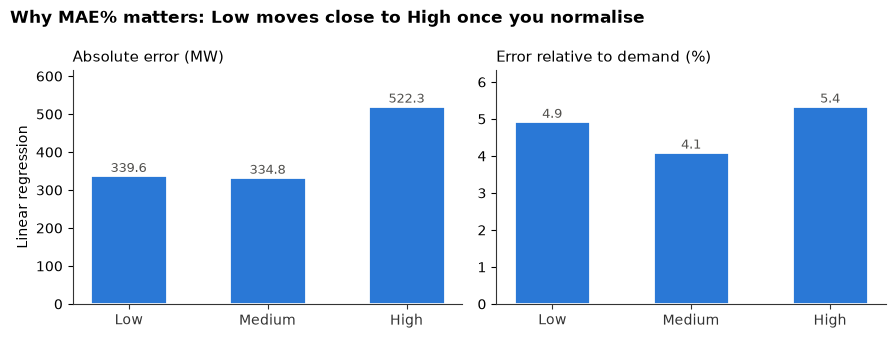

In [12]:
# Visualise why MAE% is necessary:
level = stratified[(stratified['Dimension'] == 'Demand Level') &
                   (stratified['Model'] == 'Linear Regression')].set_index('Group')
plt.style.use('default')
plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.facecolor': 'white',
    'text.color': '#333333', 'axes.labelcolor': '#333333',
    'xtick.color': '#333333', 'ytick.color': '#333333', 'axes.edgecolor': '#333333'})

fig, axes = plt.subplots(1, 2, figsize=(9, 3.4), facecolor='white')
for ax, metric, label in zip(axes, ['MAE (MW)', 'MAE (%)'],
                             ['Absolute error (MW)', 'Error relative to demand (%)']):
    ax.bar(level.index, level[metric], width=0.55, color='#2a78d6', edgecolor='white', linewidth=2)
    ax.tick_params(axis='y', colors='black', left=True, labelleft=True)
    for x, v in zip(level.index, level[metric]):
        ax.text(x, v, f'{v:,.1f}', ha='center', va='bottom', fontsize=9, color='#52514e')
    ax.set_title(label, fontsize=11, loc='left', color='black')
    ax.set_facecolor('white')
    ax.spines[['top','right']].set_visible(False)
    ax.margins(y=0.18)
axes[0].set_ylabel('Linear regression', color='black')
fig.suptitle('Why MAE% matters: Low moves close to High once you normalise',
             x=0.01, ha='left', fontsize=12, fontweight='bold', color='black')
fig.tight_layout()
plt.show()

## Feature Analysis: With vs. Without Radiation

In [13]:
# Excluding solar radiation feature from the list:
features_excl_radiation = [col for col in FEATURES if col != 'radiation_day_before']
radiation_groups = {'With Radiation': (LinearRegression().fit(train[FEATURES], train[TARGET]), FEATURES),
                    'Without Radiation': (LinearRegression().fit(train[features_excl_radiation], train[TARGET]), features_excl_radiation)}

# Set the python to predict based on with and without radiation:
def predict(name, data):
    model, feats = radiation_groups[name]
    preds = pd.Series(model.predict(data[feats]), index=data.index, name=name)
    return preds

rows = [{'Split': split, **evaluate(data[TARGET], predict(name, data), model=name)}
        for split, data in [('Validation 2018', validation), ('Test 2019', test)]
        for name in radiation_groups]

ablation = pd.DataFrame(rows).set_index(['Split', 'Model']).drop(columns='n')
print(f'Linear Baseline, {len(FEATURES)} features vs. {len(features_excl_radiation)} features')
print(ablation.to_string(float_format=lambda x: f'{x:,.2f}'))

delta = ablation.xs('Without Radiation', level='Model') - ablation.xs('With Radiation', level='Model')
print('\nEffect of Dropping "radiation_day_before"')
print('(Positive MAE / RMSE / MAPE means dropping it made the model worse:')
print(delta.to_string(float_format=lambda x: f'{x:+,.3f}'))

Linear Baseline, 47 features vs. 47 features
                                   MAE (MW)  RMSE (MW)  MAPE (%)   r2  Bias (MW)
Split           Model                                                           
Validation 2018 With Radiation       354.64     485.74      4.42 0.83     -51.25
                Without Radiation    354.64     485.74      4.42 0.83     -51.25
Test 2019       With Radiation       379.97     535.83      4.74 0.82     -58.94
                Without Radiation    379.97     535.83      4.74 0.82     -58.94

Effect of Dropping "radiation_day_before"
(Positive MAE / RMSE / MAPE means dropping it made the model worse:
                 MAE (MW)  RMSE (MW)  MAPE (%)     r2  Bias (MW)
Split                                                           
Validation 2018    +0.000     +0.000    +0.000 +0.000     +0.000
Test 2019          +0.000     +0.000    +0.000 +0.000     +0.000


## Results Visualisation

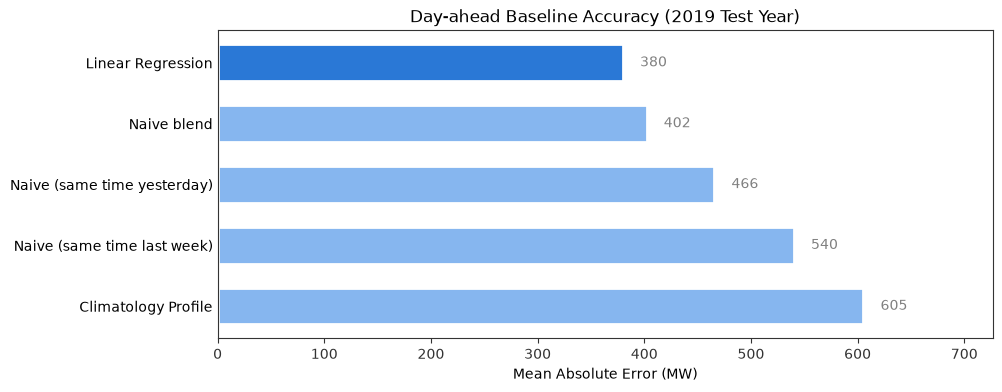

In [14]:
# Visualise the results - baseline models comparison:
t = results['Test 2019'].iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 4), facecolor='white')
ax.set_facecolor('white')
colours = ['#2a78d6' if 'linear' in m.lower() else '#86b6ef' for m in t.index]
bars = ax.barh(t.index, t['MAE (MW)'], height=0.6, color=colours, edgecolor='white', linewidth=2)
for bar, v in zip(bars, t['MAE (MW)']):
    ax.text(bar.get_width() + 16, bar.get_y() + bar.get_height()/2, f'{v:,.0f}', ha='left', va='center', color='gray')
ax.set_title('Day-ahead Baseline Accuracy (2019 Test Year)', color='black')
ax.set_xlabel('Mean Absolute Error (MW)', color='black')
ax.tick_params(axis='y', colors='black', length=0)
ax.set_xlim(0, t['MAE (MW)'].max()*1.2)
plt.show()

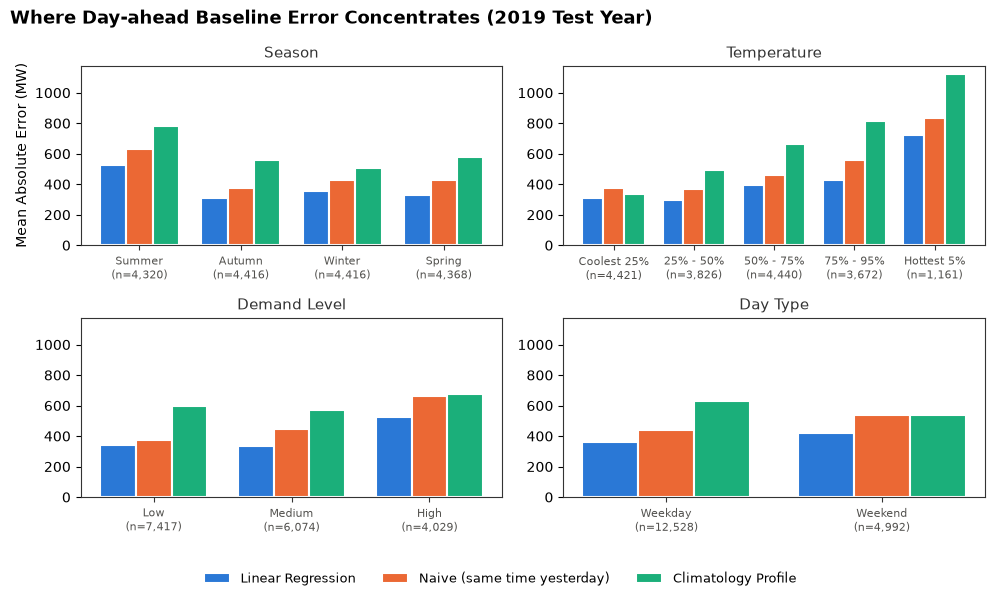

In [15]:
# Visualise Accuracy across conditions:
rep_colours = dict(zip(REPORTED, ["#2a78d6", "#eb6834", "#1baf7a"]))

fig, axes = plt.subplots(2, 2, figsize=(10, 6), facecolor='white', sharey=True, gridspec_kw={'width_ratios': [2, 2]})
width = 0.26
axes_flat = axes.flatten()
for ax, (dim, (_, label)) in zip(axes_flat, DIMENSIONS.items()):
    ax.set_facecolor('white')
    ax.tick_params(axis='y', colors='black', left=True, labelleft=True)
    df_dim = stratified[stratified['Dimension'] == dim].pivot(index='Group', columns='Model',
                                                              values='MAE (MW)').loc[label][REPORTED]
    n_values = (stratified[(stratified['Dimension'] == dim) & (stratified['Model'] == REPORTED[0])]
                .set_index('Group').loc[label, 'n'])
    x = np.arange(len(label))
    for i, m in enumerate(REPORTED):
        ax.bar(x + (i - 1) * width, df_dim[m], width=width, label=m, color=rep_colours[m],
               edgecolor='white', linewidth=1.5)
    ax.set_xticks(x, [f'{g}\n(n={n:,})' for g, n in zip(label, n_values)], fontsize=8, color='#52514e')
    ax.set_title(dim, fontsize=11)
    ax.grid(axis='y', visible=False)
axes_flat[0].set_ylabel('Mean Absolute Error (MW)', color='black')
fig.suptitle('Where Day-ahead Baseline Error Concentrates (2019 Test Year)', x=0.01,
             ha='left', fontsize=13, fontweight='bold', color='black')
handles, labels = axes_flat[0].get_legend_handles_labels()
fig.tight_layout(rect=[0, 0.08, 1, 1])
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=3, fontsize=9.5, facecolor='white',
           labelcolor='black', edgecolor='white')
plt.show()

## Get Best Baseline Model

In [16]:
# Get the best performing baseline model from the results:
best_model = results['Validation 2018']['MAE (MW)'].idxmin()
best_mae = results['Test 2019'].loc[best_model, 'MAE (MW)']
print(f'Best baseline model: {best_model} with MAE: {best_mae:,.1f} MW')

Best baseline model: Linear Regression with MAE: 380.0 MW


## Save Result: Best Baseline

In [17]:
comment = '''
Linear Regression on the 48 shared features achieves MAE 380 MW on the 2019 test year, ahead of the naive same-time-yesterday (466 MW) and Climatology Profile (605 MW) baselines, and was selected on the 2018 validation year where it also ranked the first. Features are day-before demand, temperature and radiation, public holiday and school term flags, and one-hot day, hour and month encodings. Excluded same-day weather and the AEMO forecast columns so that the model uses only information available a day ahead. Accuracy degrades in extreme heat (hottest 5%: MAE 710 MW) and at high demand (520 MW), with a 66 MW over-prediction bias relfecting the fall in average demand between the training years and test 2019.
'''

In [18]:
MODEL_NAME

'baseline_no_radiation_day_before'

In [19]:
# Save best baseline predictions:
best_preds = preds['Test 2019'][best_model]
pd.Series(best_preds, index=test.index, name=MODEL_NAME).to_csv(RESULTS_DIR / f"{MODEL_NAME}_predictions.csv")

# GEt best baseline result and clean-up:
this_run = results['Test 2019'].loc[[best_model]].reset_index().rename(columns={'index': 'model'}).iloc[:, 2:]
this_run['model'] = MODEL_NAME+'_' + best_model.replace(' ', '_').lower()
this_run.columns = [col.lower().replace(' (mw)', '').replace(' (%)', '_pct')for col in this_run.columns]
this_run = this_run[['model', 'rmse', 'mae', 'mape_pct', 'r2']]
print(this_run)
this_run['comments'] = comment

# Save best baseline's metrics to result directory:
comparison_path = RESULTS_DIR / "model_comparison.csv"
if comparison_path.exists():
    existing = pd.read_csv(comparison_path)
    existing = existing[~existing["model"].astype(str).str.startswith(MODEL_NAME)]
    this_run = pd.concat([existing, this_run], ignore_index=True)

this_run.to_csv(comparison_path, index=False)
print(this_run)

                                               model        rmse         mae  \
0  baseline_no_radiation_day_before_linear_regres...  535.832513  379.974174   

  mape_pct        r2  
0  4.73639  0.816199  
                                               model        rmse         mae  \
0                                      random_forest  493.696778  322.451412   
1                              aemo_forecast_closest   64.292411   47.711611   
2                           aemo_forecast_12hr_prior  212.913694   155.94526   
3                             aemo_forecast_dayprior  222.460754  161.830989   
4                                            xgboost  470.544565    311.1764   
5                                           lightgbm  463.995139  307.403004   
6                                            prophet  469.383322  345.777006   
7                         baseline_linear_regression   535.98912  380.215288   
8  baseline_no_radiation_day_before_linear_regres...  535.832513  379.974